In [ ]:
import pandas as pd
import glob
import re
import os

folder_path = "/content/"
all_files = glob.glob(os.path.join(folder_path, "filtered_*_*.csv"))


In [ ]:
df_full = pd.read_csv("/content/combined_with_subjID.csv")

In [ ]:
env_ranges = {
    1: (2, 61),
    2: (62, 121),
    3: (122, 181),
    4: (182, 241)
}

env_rows = {
    1: [7, 13, 19, 25, 31, 37, 43, 49, 55, 61],
    2: [67, 73, 79, 85, 91, 97, 103, 109, 115, 121],
    3: [127, 133, 139, 145, 151, 157, 163, 169, 175, 181],
    4: [187, 193, 199, 205, 211, 217, 223, 229, 235, 241]
    }

def filter_dataframe_rows(df, start_row, end_row, skip_rows=None):
    mask = pd.Series(False, index=df.index)
    mask.iloc[start_row:end_row + 1] = True

    mask[skip_rows] = False

    filtered_df = df.loc[mask[mask].index].copy()
    return filtered_df


In [ ]:
env1 = []
env2 = []
env3 = []
env4= []

In [ ]:
for file in all_files:
    match = re.search(r"filtered_(\d+)_", os.path.basename(file))

    participant_id = int(match.group(1))

    df_each = pd.read_csv(file)

    i=1

    env_list = []

    for env, (start, end) in env_ranges.items():
        env_trials = filter_dataframe_rows(df_each, start, end, env_rows[i])
        env_trials['subjID'] = participant_id
        i = i + 1
        env_list.append(env_trials)

    env1.append(env_list[0])
    env2.append(env_list[1])
    env3.append(env_list[2])
    env4.append(env_list[3])

In [ ]:
env1

[    stressSlider.response  total_score  delta_score chosen_image  best_island  \
 2                1.990000         1.00         1.00      image_1          1.0   
 3                1.990000         2.00         1.00      image_3          1.0   
 4                1.990000         1.00        -1.00      image_3          1.0   
 5                1.990000         0.00        -1.00      image_3          1.0   
 6                1.990000        -1.00        -1.00      image_2          1.0   
 8                2.020000        -2.00        -1.00      image_1          1.0   
 9                2.020000        -3.00        -1.00      image_3          1.0   
 10               2.020000        -2.00         1.00      image_3          1.0   
 11               2.020000        -3.00        -1.00      image_3          1.0   
 12               2.020000        -2.00         1.00      image_2          1.0   
 14               2.163333        -1.00         1.00      image_1          2.0   
 15             

In [ ]:
df_cleaned = df_full.copy()

df_cleaned = df_cleaned.dropna(subset=['best_island'])

In [ ]:
env1_df = pd.concat(env1, ignore_index=True)
env2_df = pd.concat(env2, ignore_index=True)
env3_df = pd.concat(env3, ignore_index=True)
env4_df = pd.concat(env4, ignore_index=True)

In [ ]:
import numpy as np

mapping = {'image_1': 1, 'image_2': 2, 'image_3': 3}

# Use the .map() function to apply the mapping to the column
env1_df['choice'] = env1_df['chosen_image'].map(mapping)
env2_df['choice'] = env2_df['chosen_image'].map(mapping)
env3_df['choice'] = env3_df['chosen_image'].map(mapping)
env4_df['choice'] = env4_df['chosen_image'].map(mapping)

In [ ]:
df_cleaned['choice'] = df_cleaned['chosen_image'].map(mapping)
df_cleaned = df_cleaned.dropna(subset=['choice'])

In [ ]:
env1_df = env1_df.dropna(subset=['choice'])
env2_df = env2_df.dropna(subset=['choice'])
env3_df = env3_df.dropna(subset=['choice'])
env4_df = env4_df.dropna(subset=['choice'])

In [ ]:
env1_df['gain'] = env1_df['delta_score'].apply(lambda x: x if x >= 0 else 0)
env2_df['gain'] = env2_df['delta_score'].apply(lambda x: x if x >= 0 else 0)
env3_df['gain'] = env3_df['delta_score'].apply(lambda x: x if x >= 0 else 0)
env4_df['gain'] = env4_df['delta_score'].apply(lambda x: x if x >= 0 else 0)

env1_df['loss'] = env1_df['delta_score'].apply(lambda x: x if x < 0 else 0)
env2_df['loss'] = env2_df['delta_score'].apply(lambda x: x if x < 0 else 0)
env3_df['loss'] = env3_df['delta_score'].apply(lambda x: x if x < 0 else 0)
env4_df['loss'] = env4_df['delta_score'].apply(lambda x: x if x < 0 else 0)

In [ ]:
df_cleaned['gain'] = df_cleaned['delta_score'].apply(lambda x: x if x >= 0 else 0)
df_cleaned['loss'] = df_cleaned['delta_score'].apply(lambda x: x if x < 0 else 0)

In [ ]:
columns_to_keep = ['subjID', 'gain', 'loss', 'choice']  # Replace with your desired columns
env1_df = env1_df[columns_to_keep]
env2_df = env2_df[columns_to_keep]
env3_df = env3_df[columns_to_keep]
env4_df = env4_df[columns_to_keep]

env1_df['choice'] = env1_df['choice'].astype(int)
env2_df['choice'] = env2_df['choice'].astype(int)
env3_df['choice'] = env3_df['choice'].astype(int)
env4_df['choice'] = env4_df['choice'].astype(int)

In [ ]:
df_cleaned = df_cleaned[columns_to_keep]
df_cleaned['choice'] = df_cleaned['choice'].astype(int)

<ipython-input-45-2530d75a7c12>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['choice'] = df_cleaned['choice'].astype(int)


In [ ]:
env1_df.to_csv("env1.txt", sep="\t", index=False)
env2_df.to_csv("env2.txt", sep="\t", index=False)
env3_df.to_csv("env3.txt", sep="\t", index=False)
env4_df.to_csv("env4.txt", sep="\t", index=False)

In [ ]:
df_cleaned.to_csv("full_data.txt", sep="\t", index=False)

In [ ]:
import pandas as pd

df_olife = pd.read_excel("/content/olife_high_low.xlsx")

In [ ]:
high_ss1_participant_index = list(df_olife[df_olife["ss1 Type"] == 'High ss1']["Participant ID"])

In [ ]:
high_ss1_participant_index

[101,
 102,
 105,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 115,
 121,
 122,
 132,
 133,
 134,
 135,
 136,
 'Nitesh']

In [ ]:
low_ss1_participant_index = list(df_olife[df_olife["ss1 Type"] == 'Low ss1']["Participant ID"])

In [ ]:
low_ss1_participant_index

[103,
 104,
 106,
 114,
 116,
 117,
 118,
 119,
 120,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 137]

In [ ]:
env1_df = pd.read_csv("/content/env1.txt", sep="\t")
env2_df = pd.read_csv("/content/env2.txt", sep="\t")
env3_df = pd.read_csv("/content/env3.txt", sep="\t")
env4_df = pd.read_csv("/content/env4.txt", sep="\t")

In [ ]:
env1_df_high_ss1 = env1_df[env1_df["subjID"].isin(high_ss1_participant_index)]
env1_df_low_ss1 = env1_df[env1_df["subjID"].isin(low_ss1_participant_index)]

In [ ]:
env2_df_high_ss1 = env2_df[env2_df["subjID"].isin(high_ss1_participant_index)]
env2_df_low_ss1 = env2_df[env2_df["subjID"].isin(low_ss1_participant_index)]

In [ ]:
env3_df_high_ss1 = env3_df[env3_df["subjID"].isin(high_ss1_participant_index)]
env3_df_low_ss1 = env3_df[env3_df["subjID"].isin(low_ss1_participant_index)]

In [ ]:
env4_df_high_ss1 = env4_df[env4_df["subjID"].isin(high_ss1_participant_index)]
env4_df_low_ss1 = env4_df[env4_df["subjID"].isin(low_ss1_participant_index)]

In [ ]:
env1_df_high_ss1.to_csv("env1_data_high_ss1.txt", sep="\t", index=False)
env1_df_low_ss1.to_csv("env1_data_low_ss1.txt", sep="\t", index=False)
env2_df_high_ss1.to_csv("env2_data_high_ss2.txt", sep="\t", index=False)
env2_df_low_ss1.to_csv("env2_data_low_ss2.txt", sep="\t", index=False)
env3_df_high_ss1.to_csv("env3_data_high_ss3.txt", sep="\t", index=False)
env3_df_low_ss1.to_csv("env3_data_low_ss4.txt", sep="\t", index=False)
env4_df_high_ss1.to_csv("env4_data_high_ss4.txt", sep="\t", index=False)
env4_df_low_ss1.to_csv("env4_data_low_ss4.txt", sep="\t", index=False)


<ipython-input-2-085b0ed80f40>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='Block', y='Arew', data=all_data, palette=custom_palette)


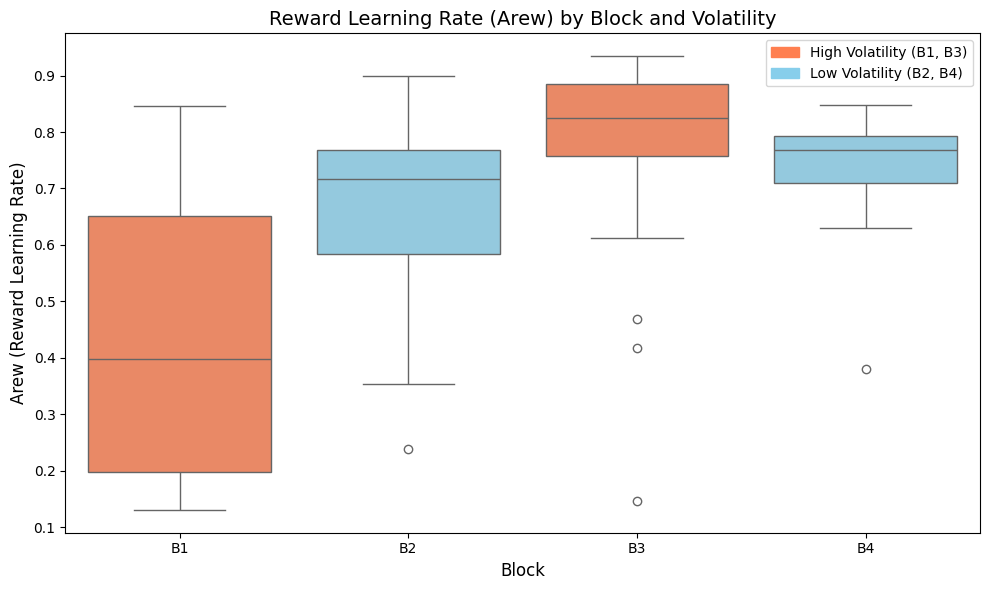

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from each CSV file
b1 = pd.read_csv('individual_parameters_B1.csv')
b2 = pd.read_csv('individual_parameters_B2.csv')
b3 = pd.read_csv('individual_parameters_B3.csv')
b4 = pd.read_csv('individual_parameters_B4.csv')

# Add a 'Block' column to each dataframe
b1['Block'] = 'B1'
b2['Block'] = 'B2'
b3['Block'] = 'B3'
b4['Block'] = 'B4'

# Combine all data into one dataframe
all_data = pd.concat([b1, b2, b3, b4])

# Create a custom palette (high volatility: coral, low volatility: skyblue)
custom_palette = ['coral', 'skyblue', 'coral', 'skyblue']

# Create the boxplot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='Block', y='Arew', data=all_data, palette=custom_palette)

# Add legend for volatility levels
import matplotlib.patches as mpatches
high_patch = mpatches.Patch(color='coral', label='High Volatility (B1, B3)')
low_patch = mpatches.Patch(color='skyblue', label='Low Volatility (B2, B4)')
plt.legend(handles=[high_patch, low_patch])

# Add title and labels
plt.title('Reward Learning Rate (Arew) by Block and Volatility', fontsize=14)
plt.xlabel('Block', fontsize=12)
plt.ylabel('Arew (Reward Learning Rate)', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

<ipython-input-5-236307ef8f09>:50: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


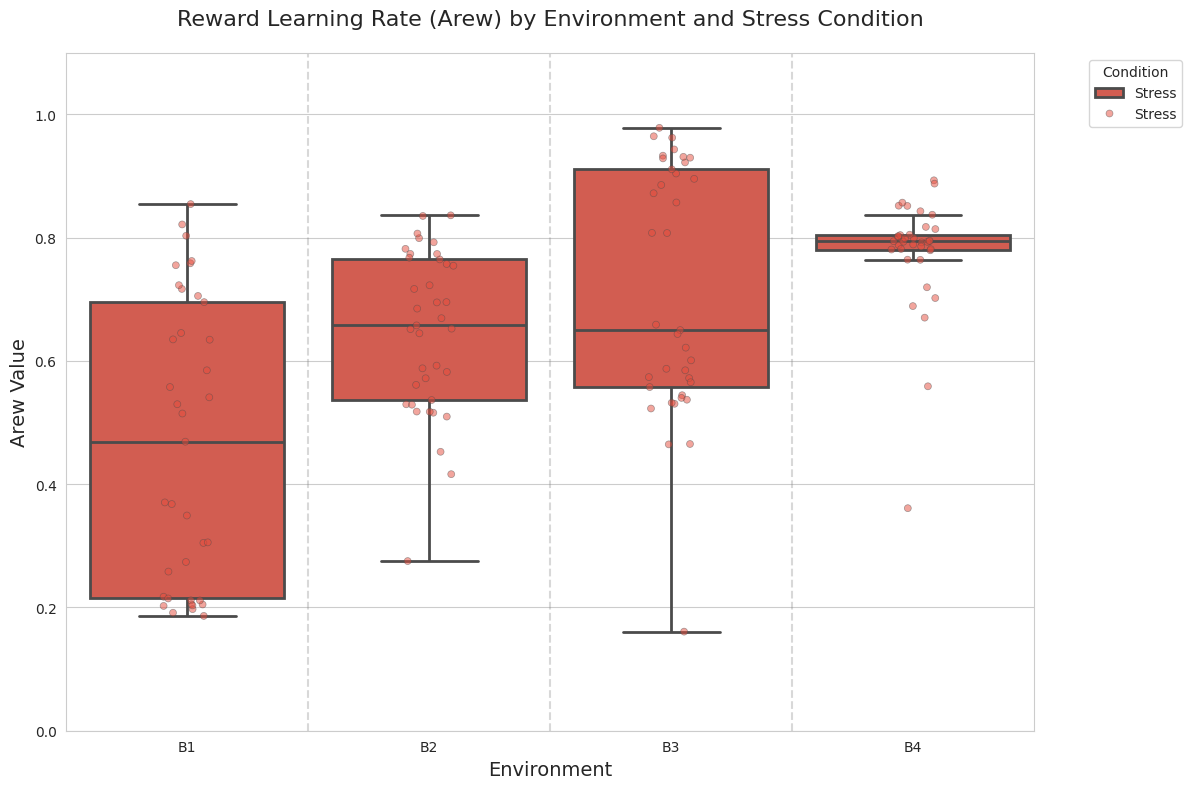

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load all data files
files = {
    'env1_nostress': 'individual_parameters_env1_nostress.csv',
    'env1_stress': 'individual_parameters_env1_stress.csv',
    'env2_nostress': 'individual_parameters_env2_nostress.csv',
    'env2_stress': 'individual_parameters_env2_stress.csv',
    'env3_nostress': 'individual_parameters_env3_nostress.csv',
    'env3_stress': 'individual_parameters_env3_stress.csv',
    'env4_nostress': 'individual_parameters_env4_nostress.csv',
    'env4_stress': 'individual_parameters_env4_stress.csv'
}

# Create and combine all dataframes
dfs = []
for name, file in files.items():
    df = pd.read_csv(file)
    env_num = int(name[3])  # Extract environment number
    stress = 'stress' in name
    df['Environment'] = f'B{env_num}'
    df['Stress'] = 'Stress' if stress else 'No Stress'
    dfs.append(df)

all_data = pd.concat(dfs)

# Create the plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Custom palette (red for stress, green for no stress)
palette = {'Stress': '#e74c3c', 'No Stress': '#2ecc71'}

# Create boxplot
ax = sns.boxplot(
    x='Environment',
    y='Arew',
    hue='Stress',
    data=all_data,
    order=['B1', 'B2', 'B3', 'B4'],
    palette=palette,
    linewidth=2,
    showfliers=False
)

# Add stripplot for individual points
sns.stripplot(
    x='Environment',
    y='Arew',
    hue='Stress',
    data=all_data,
    order=['B1', 'B2', 'B3', 'B4'],
    palette=palette,
    dodge=True,
    alpha=0.5,
    size=5,
    edgecolor='gray',
    linewidth=0.5
)

# Customize plot
plt.title('Reward Learning Rate (Arew) by Environment and Stress Condition',
          fontsize=16, pad=20)
plt.xlabel('Environment', fontsize=14)
plt.ylabel('Arew Value', fontsize=14)
plt.ylim(0, 1.1)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Condition',
           bbox_to_anchor=(1.05, 1), loc='upper left')

# Add separation between environments
for i in range(3):
    plt.axvline(x=i+0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<ipython-input-14-9d063883e333>:76: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


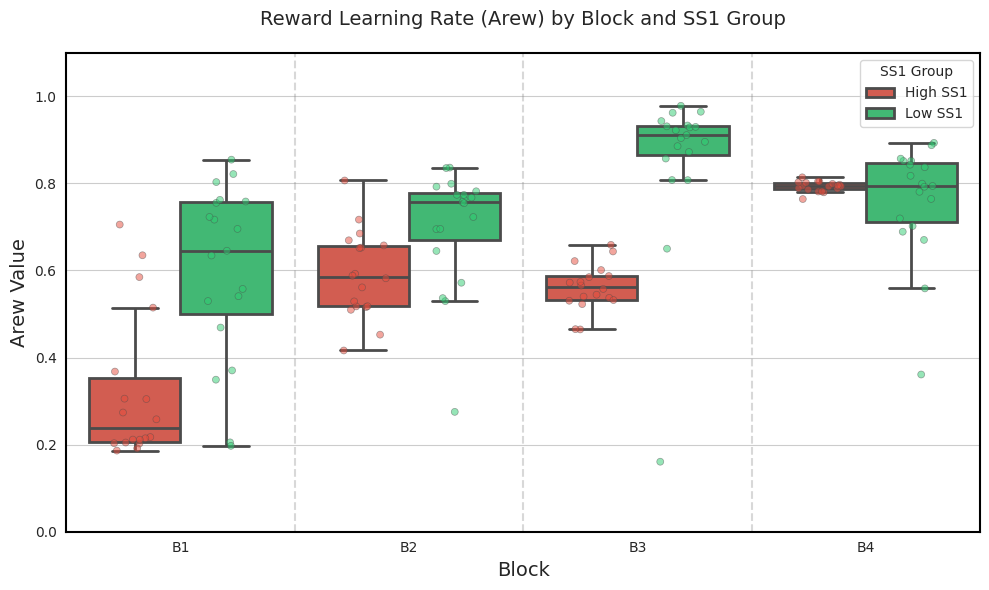

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and label the data
data_frames = []

# Environment 1
b1_high = pd.read_csv('individual_parameters_env1_stress.csv')
b1_high['Block'] = 'B1'
b1_high['SS1_Group'] = 'High SS1'
data_frames.append(b1_high)

b1_low = pd.read_csv('individual_parameters_env1_nostress.csv')
b1_low['Block'] = 'B1'
b1_low['SS1_Group'] = 'Low SS1'
data_frames.append(b1_low)

# Environment 2
b2_high = pd.read_csv('individual_parameters_env2_stress.csv')
b2_high['Block'] = 'B2'
b2_high['SS1_Group'] = 'High SS1'
data_frames.append(b2_high)

b2_low = pd.read_csv('individual_parameters_env2_nostress.csv')
b2_low['Block'] = 'B2'
b2_low['SS1_Group'] = 'Low SS1'
data_frames.append(b2_low)

# Environment 3
b3_high = pd.read_csv('individual_parameters_env3_stress.csv')
b3_high['Block'] = 'B3'
b3_high['SS1_Group'] = 'High SS1'
data_frames.append(b3_high)

b3_low = pd.read_csv('individual_parameters_env3_nostress.csv')
b3_low['Block'] = 'B3'
b3_low['SS1_Group'] = 'Low SS1'
data_frames.append(b3_low)

# Environment 4
b4_high = pd.read_csv('individual_parameters_env4_stress.csv')
b4_high['Block'] = 'B4'
b4_high['SS1_Group'] = 'High SS1'
data_frames.append(b4_high)

b4_low = pd.read_csv('individual_parameters_env4_nostress.csv')
b4_low['Block'] = 'B4'
b4_low['SS1_Group'] = 'Low SS1'
data_frames.append(b4_low)

# Combine all data
all_data = pd.concat(data_frames)

# Create the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Custom color palette
palette = {'High SS1': '#e74c3c', 'Low SS1': '#2ecc71'}  # Red and green

# Create boxplot
ax = sns.boxplot(
    x='Block',
    y='Arew',
    hue='SS1_Group',
    data=all_data,
    order=['B1', 'B2', 'B3', 'B4'],
    palette=palette,
    linewidth=2,
    showfliers=False
)

# Add individual data points
sns.stripplot(
    x='Block',
    y='Arew',
    hue='SS1_Group',
    data=all_data,
    order=['B1', 'B2', 'B3', 'B4'],
    palette=palette,
    dodge=True,
    alpha=0.5,
    size=5,
    edgecolor='gray',
    linewidth=0.5,
    jitter=0.2
)

# Customize plot
plt.title('Reward Learning Rate (Arew) by Block and SS1 Group', fontsize=14, pad=20)
plt.xlabel('Block', fontsize=14)
plt.ylabel('Arew Value', fontsize=14)
plt.ylim(0, 1.1)

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='SS1 Group',
           loc='upper right', frameon=True)


# Add vertical separators between blocks
for i in range(3):
    plt.axvline(x=i+0.5, color='gray', linestyle='--', alpha=0.3)

# Make plot boundary (spines) black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


<ipython-input-5-b47f06e249a2>:76: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


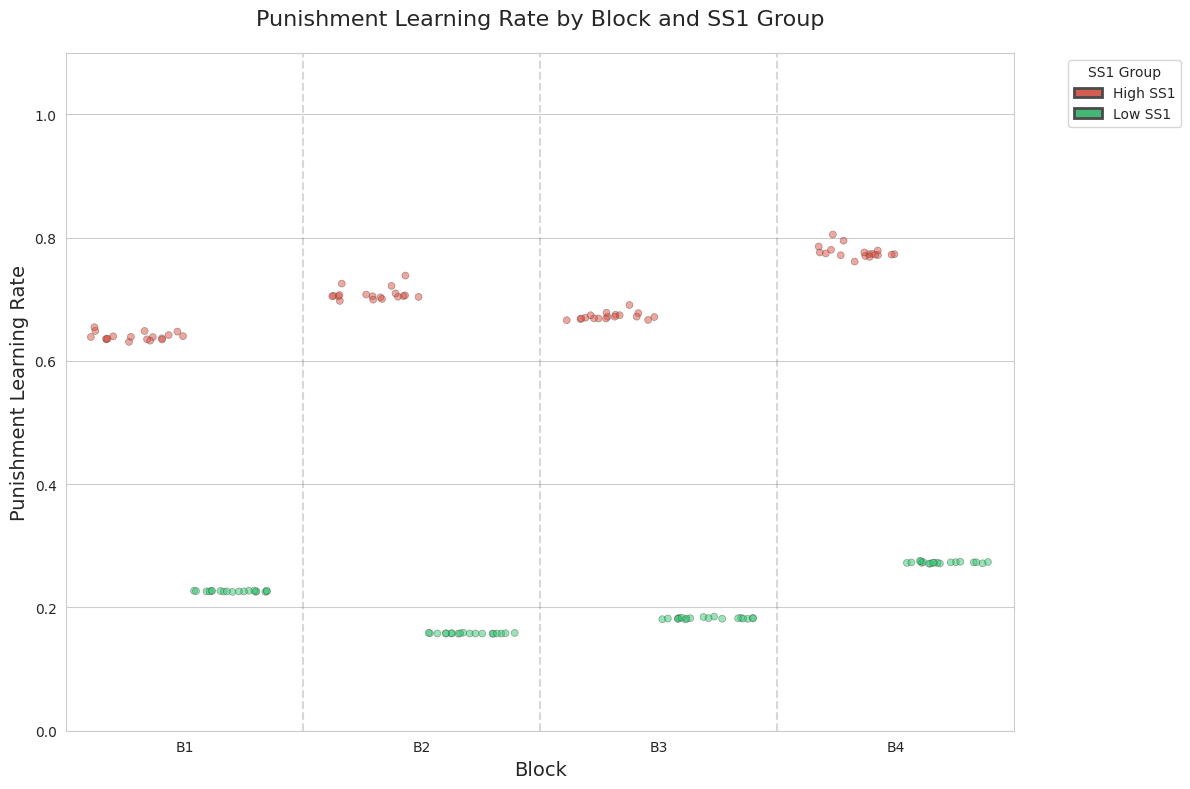

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and label the data
data_frames = []

# Environment 1
b1_high = pd.read_csv('individual_parameters_env1_stress.csv')
b1_high['Block'] = 'B1'
b1_high['SS1_Group'] = 'High SS1'
data_frames.append(b1_high)

b1_low = pd.read_csv('individual_parameters_env1_nostress.csv')
b1_low['Block'] = 'B1'
b1_low['SS1_Group'] = 'Low SS1'
data_frames.append(b1_low)

# Environment 2
b2_high = pd.read_csv('individual_parameters_env2_stress.csv')
b2_high['Block'] = 'B2'
b2_high['SS1_Group'] = 'High SS1'
data_frames.append(b2_high)

b2_low = pd.read_csv('individual_parameters_env2_nostress.csv')
b2_low['Block'] = 'B2'
b2_low['SS1_Group'] = 'Low SS1'
data_frames.append(b2_low)

# Environment 3
b3_high = pd.read_csv('individual_parameters_env3_stress.csv')
b3_high['Block'] = 'B3'
b3_high['SS1_Group'] = 'High SS1'
data_frames.append(b3_high)

b3_low = pd.read_csv('individual_parameters_env3_nostress.csv')
b3_low['Block'] = 'B3'
b3_low['SS1_Group'] = 'Low SS1'
data_frames.append(b3_low)

# Environment 4
b4_high = pd.read_csv('individual_parameters_env4_stress.csv')
b4_high['Block'] = 'B4'
b4_high['SS1_Group'] = 'High SS1'
data_frames.append(b4_high)

b4_low = pd.read_csv('individual_parameters_env4_nostress.csv')
b4_low['Block'] = 'B4'
b4_low['SS1_Group'] = 'Low SS1'
data_frames.append(b4_low)

# Combine all data
all_data = pd.concat(data_frames)

# Create the plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Custom color palette
palette = {'High SS1': '#e74c3c', 'Low SS1': '#2ecc71'}  # Red and green

# # Create boxplot
# ax = sns.boxplot(
#     x='Block',
#     y='Apun',
#     hue='SS1_Group',
#     data=all_data,
#     order=['B1', 'B2', 'B3', 'B4'],
#     palette=palette,
#     linewidth=2,
#     showfliers=False
# )

# Add individual data points
sns.stripplot(
    x='Block',
    y='Apun',
    hue='SS1_Group',
    data=all_data,
    order=['B1', 'B2', 'B3', 'B4'],
    palette=palette,
    dodge=True,
    alpha=0.5,
    size=5,
    edgecolor='gray',
    linewidth=0.5,
    jitter=0.4
)

# Customize plot
plt.title('Punishment Learning Rate by Block and SS1 Group', fontsize=16, pad=20)
plt.xlabel('Block', fontsize=14)
plt.ylabel('Punishment Learning Rate', fontsize=14)
plt.ylim(0, 1.1)

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='SS1 Group',
           bbox_to_anchor=(1.05, 1), loc='upper left')

# Add vertical separators between blocks
for i in range(3):
    plt.axvline(x=i+0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations

# [Previous data loading code remains the same until after all_data is created...]

# Combine all data
all_data = pd.concat(data_frames)

# 1. First perform two-way ANOVA (Block × SS1_Group)
model = ols('Arew ~ C(Block) + C(SS1_Group) + C(Block):C(SS1_Group)', data=all_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Two-way ANOVA results:")
print(anova_table)
print("\n" + "="*80 + "\n")

# 2. Perform pairwise t-tests within each block
blocks = ['B1', 'B2', 'B3', 'B4']
results = []

for block in blocks:
    high = all_data[(all_data['Block'] == block) & (all_data['SS1_Group'] == 'High SS1')]['Arew']
    low = all_data[(all_data['Block'] == block) & (all_data['SS1_Group'] == 'Low SS1')]['Arew']

    # Welch's t-test (doesn't assume equal variances)
    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((high.std()**2 + low.std()**2)/2)
    cohens_d = (high.mean() - low.mean()) / pooled_std

    results.append({
        'Block': block,
        't-statistic': t_stat,
        'p-value': p_val,
        'Cohen\'s d': cohens_d,
        'High_mean': high.mean(),
        'Low_mean': low.mean()
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("Pairwise comparisons (High vs Low SS1 within each block):")
print(results_df.to_markdown(index=False))

Two-way ANOVA results:
                         sum_sq     df          F        PR(>F)
C(Block)               2.011560    3.0  34.955055  6.328073e-17
C(SS1_Group)           0.977832    1.0  50.975582  4.649314e-11
C(Block):C(SS1_Group)  0.653076    3.0  11.348552  1.041437e-06
Residual               2.685529  140.0        NaN           NaN


Pairwise comparisons (High vs Low SS1 within each block):
| Block   |   t-statistic |     p-value |   Cohen's d |   High_mean |   Low_mean |
|:--------|--------------:|------------:|------------:|------------:|-----------:|
| B1      |      -4.54738 | 6.41146e-05 |   -1.49215  |    0.321857 |   0.599446 |
| B2      |      -2.8011  | 0.00849316  |   -0.917317 |    0.590119 |   0.700415 |
| B3      |      -6.67329 | 1.31785e-06 |   -2.16956  |    0.561274 |   0.854968 |
| B4      |       1.04789 | 0.308325    |    0.340057 |    0.792664 |   0.761588 |


In [8]:
results_df.to_csv("ANOVA_pairwise_comparisons.csv")

<ipython-input-16-9101d0486698>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
<ipython-input-16-9101d0486698>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
<ipython-input-16-9101d0486698>:41: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


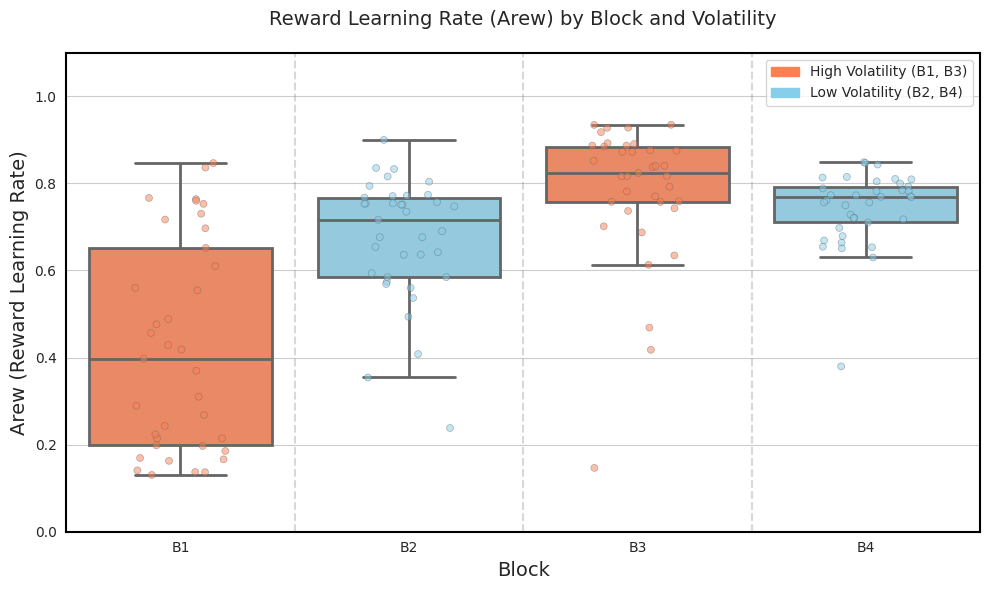

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Load the data from each CSV file
b1 = pd.read_csv('individual_parameters_B1.csv')
b2 = pd.read_csv('individual_parameters_B2.csv')
b3 = pd.read_csv('individual_parameters_B3.csv')
b4 = pd.read_csv('individual_parameters_B4.csv')

# Add a 'Block' column to each dataframe
b1['Block'] = 'B1'
b2['Block'] = 'B2'
b3['Block'] = 'B3'
b4['Block'] = 'B4'

# Combine all data into one dataframe
all_data = pd.concat([b1, b2, b3, b4])

# Create a custom palette (high volatility: coral, low volatility: skyblue)
custom_palette = ['coral', 'skyblue', 'coral', 'skyblue']

# Set plot style
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(
    x='Block',
    y='Arew',
    data=all_data,
    palette=custom_palette,
    linewidth=2,
    showfliers=False
)

# Stripplot overlay
sns.stripplot(
    x='Block',
    y='Arew',
    data=all_data,
    palette=custom_palette,
    dodge=False,
    alpha=0.5,
    size=5,
    edgecolor='gray',
    linewidth=0.5,
    jitter=0.2
)

# Legend
high_patch = mpatches.Patch(color='coral', label='High Volatility (B1, B3)')
low_patch = mpatches.Patch(color='skyblue', label='Low Volatility (B2, B4)')
plt.legend(handles=[high_patch, low_patch], loc='upper right', frameon=True)

# Titles and labels
plt.title('Reward Learning Rate (Arew) by Block and Volatility', fontsize=14, pad=20)
plt.xlabel('Block', fontsize=14)
plt.ylabel('Arew (Reward Learning Rate)', fontsize=14)
plt.ylim(0, 1.1)

# Add vertical separators between blocks
for i in range(3):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', alpha=0.3)

# Make border of plot black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(1.5)


plt.tight_layout()
plt.show()
